In this notebook, we will perform transfer learning using EfficientNetB0 on MNIST. I will explain the architecture behind EfficientNetB0 as well as the concept behind transfer learning

In [ ]:
# Notebook parameters

BATCH_SIZE = 64
VALID_BATCH_SIZE = 100
TEST_BATCH_SIZE = 100
EPOCHS = 5
NUM_CLASSES = 10
SEED = 42
EARLY_STOPPING = 25
OUTPUT_DIR = '/kaggle/working/'
MODEL_NAME = 'efficientnet-b0'

In [ ]:
!pip install efficientnet-pytorch

## Import necessary libraries

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import accuracy_score
from PIL import Image, ImageOps, ImageEnhance
from efficientnet_pytorch import EfficientNet

## Read in MNIST data:

In [ ]:
train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

print('Shape of the training data: ', train.shape)
print('Shape of the test data: ', test.shape)

In [ ]:
sample_df = train.groupby('label').apply(lambda x: x.sample(n=1)).reset_index(drop = True)
sample_df.drop(columns=['label'], inplace=True)

In [ ]:
nrows = 2
ncols = 5
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, gridspec_kw={'wspace': 0.01, 'hspace': 0.05},
                       squeeze=True, figsize=(10,12))

ind_y = 0
ind_x = 0
for i, row in sample_df.iterrows():
    if ind_y > ncols - 1:
        ind_y = 0
        ind_x += 1
    sample_digit = sample_df.values[i, :].reshape((28, 28))
    axs[ind_x, ind_y].axis('off')
    axs[ind_x, ind_y].imshow(sample_digit, cmap='gray')
    axs[ind_x, ind_y].set_title("Digit {}:".format(i))
    ind_y += 1

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Perform train, validation split
train_df, valid_df = train_test_split(train, test_size = 0.2, random_state=SEED,stratify=train['label'])

In [ ]:
import cv2

# Define custom data loader, 
# code adapted from https://www.kaggle.com/juiyangchang/cnn-with-pytorch-0-995-accuracy

n_pixels = len(train_df.columns) - 1


class MNIST_Dataset(Dataset):
    """MNIST data set"""
    
    def __init__(self, df
                ):
        
        if len(df.columns) == n_pixels:
            # test data
            self.X = df.values.reshape((-1,28,28)).astype(np.uint8)[:,:,:,None]
            self.y = None
            
            self.X3 = np.full((self.X.shape[0], 3, 28, 28), 0.0)

            for i, s in enumerate(self.X):
                self.X3[i] = np.moveaxis(cv2.cvtColor(s, cv2.COLOR_GRAY2RGB), -1, 0)
                
        else:
            # training/validation data
            self.X = df.iloc[:,1:].values.reshape((-1,28,28)).astype(np.uint8)[:,:,:,None]
            self.y = torch.from_numpy(df.iloc[:,0].values)
            
            self.X3 = np.full((self.X.shape[0], 3, 28, 28), 0.0)

            for i, s in enumerate(self.X):
                self.X3[i] = np.moveaxis(cv2.cvtColor(s, cv2.COLOR_GRAY2RGB), -1, 0)
    
    def __len__(self):
        return len(self.X3)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X3[idx] , self.y[idx]
        else:
            return self.X3[idx]

In [ ]:
train_dataset = MNIST_Dataset(train_df)
valid_dataset = MNIST_Dataset(valid_df)
test_dataset = MNIST_Dataset(test)


train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=BATCH_SIZE,
                                           shuffle=True)
valid_loader = torch.utils.data.DataLoader(dataset=valid_dataset,
                                           batch_size=VALID_BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                           batch_size=TEST_BATCH_SIZE, shuffle=False)

## Concept Behind Transfer Learning
---

First let's understand the concept behind transfer learning.

An analogy is the way humans learn. For example, we learn and gain knowledge in a certain field like math and statistics. We are able to take what we have learnt and apply to other fields.

In deep learning, there is a similar concept known as transfer learning. Transfer learning is the idea of overcoming the isolated learning paradigm and utilizing knowledge acquired for one task to solve related ones. 

For Convolutional Neural Networks, transfer learning can be done by taking weights learnt by a model architecture on a specific task (for eg, Image classification of a predefined set of images) and using these weights as a starting point, with a modified architecture, letting the new model learn for more epochs.

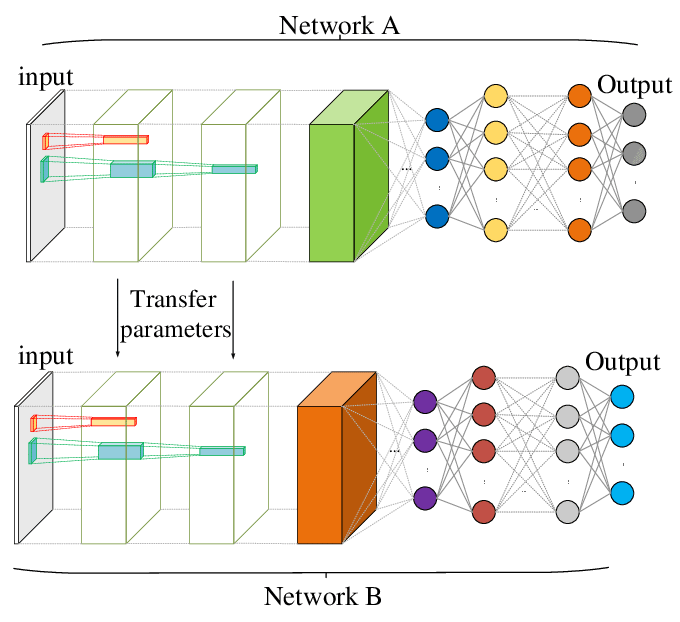

(Image from: https://researchgate.net/figure/Illustration-of-transfer-learning-concept-where-the-rst-layers-in-network-A-and-network-B_fig2_316748306)


<ins>Great, but how does Transfer Learning help in training a CNN? </ins>

* Generally, the rate of convergence of a CNN is faster when transfer learning is applied as compared to without.

## Transfer Learning using EfficientNet
---

You may have seen solutions of winning solutions in kaggle using EfficientNet. B**ut what is EfficientNet?**

EfficientNet is deep learning architecture designed by Google to tackle the problem of scaling Neural Networks (deciding how to best increase model size and increase accuracy). Given that there is a tradeoff between efficiency and accuracy in scaling CNNs, the idea by Google is to provide better accuracy and improve the efficiency of the models by reducing the parameters and FLOPS (Floating Point Operations Per Second) manifold. There is an excellent article on Medium that explains in detail, what this architecture does: https://towardsdatascience.com/efficientnet-scaling-of-convolutional-neural-networks-done-right-3fde32aef8ff

We can take the pretrained weights and the architecture provided in EfficientNet, remove the "head" of the CNN network, and add our own custom head to form a new architecture. Then train it for some epochs for our model to learn specific to the task we set it to do 

In [ ]:
## Load in pretrained effnet model and remove its head, replacing it with fully connected layer 
## that gives 10 outputs 
def get_model(model_name='efficientnet-b0'):
    model = EfficientNet.from_pretrained(model_name)
    del model._fc
    # # # use the same head as the baseline notebook.
    model._fc = nn.Linear(1280, NUM_CLASSES)
    return model

It's as simple as that! Just 6 lines of code to import the weights and architecture of pretrained efficientNet and replace its head.

Now, let's do some training with our efficientNet architecture

In [ ]:
import random
import os

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # type: ignore

In [ ]:
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output_dir = OUTPUT_DIR


model = get_model(MODEL_NAME)
model = model.to(device)

    
# # # get optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# # # get scheduler
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# # # get loss
loss_func = nn.CrossEntropyLoss()

if torch.cuda.is_available():
    model = model.cuda()
    loss_func = loss_func.cuda()

best_val_accuracy = 0
min_val_loss = np.inf
best_epoch = 0
batches = 0
epochs_no_improve = 0
n_epochs_stop = EARLY_STOPPING
for epoch in range(EPOCHS):
    running_loss = 0.0
    targets = torch.empty(size=(BATCH_SIZE, )).to(device) 
    outputs = torch.empty(size=(BATCH_SIZE, )).to(device)
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        batches += 1
        data, target = Variable(data), Variable(target)
        if torch.cuda.is_available():
            data = data.type(torch.FloatTensor).cuda()
            target = target.cuda()
        targets = torch.cat((targets, target), 0)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_func(output, target)
        output = torch.argmax(torch.softmax(output, dim=1), dim=1)
        outputs = torch.cat((outputs, output), 0)
        running_loss += loss.item()
        loss.backward()
        optimizer.step()
    scheduler.step()
    print('train/loss on EPOCH {}: {}'.format(epoch, running_loss/batches))
    train_acc = accuracy_score(targets.cpu().detach().numpy().astype(int), 
                              outputs.cpu().detach().numpy().astype(int))
    print('train/accuracy: {} for epoch {}'.format(train_acc, epoch))

    model.eval()
    # Validation loop
    running_loss = 0.0
    batches = 0
    targets = torch.empty(size=(BATCH_SIZE, )).to(device) 
    outputs = torch.empty(size=(BATCH_SIZE, )).to(device) 
    for batch_idx, (data, target) in enumerate(valid_loader):
        batches += 1
        data, target = Variable(data, volatile=True), Variable(target)
        if torch.cuda.is_available():
            data = data.type(torch.FloatTensor).cuda()
            target = target.cuda()
        with torch.no_grad():
            targets = torch.cat((targets, target), 0)
            output = model(data)
            loss = loss_func(output, target)
            output = torch.argmax(torch.softmax(output, dim=1), dim=1)
            outputs = torch.cat((outputs, output), 0)
            running_loss += loss.item()

    val_loss = running_loss/batches
    print('val/loss: {}'.format(val_loss))
    val_acc = accuracy_score(targets.cpu().detach().numpy().astype(int), 
                      outputs.cpu().detach().numpy().astype(int))
    print('val/accuracy: {} for epoch {}'.format(val_acc, epoch))



    # Model Checkpoint for best validation f1
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        min_val_loss = val_loss
        print('Best val/acc: {} for epoch {}, saving model---->'.format(val_acc, epoch))
        torch.save(model.state_dict(), "{}/snapshot_epoch_{}.pth".format(output_dir, epoch))
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve == n_epochs_stop:
        print('Early stopping!')
        break

## Prediction on Test Set

In [ ]:
def prediction(model, data_loader):
    model.eval()
    test_pred = torch.LongTensor()
    
    for i, data in enumerate(data_loader):
        data = Variable(data, volatile=True)
        if torch.cuda.is_available():
            data = data.type(torch.FloatTensor).cuda()
            
        output = model(data)
        pred = output.cpu().data.max(1, keepdim=True)[1]
        test_pred = torch.cat((test_pred, pred), dim=0)
        
    return test_pred

In [ ]:
model.load_state_dict(torch.load("snapshot_epoch_{}.pth".format(best_epoch)))
test_pred = prediction(model, test_loader)
submission = pd.DataFrame(np.c_[np.arange(1, len(test_dataset)+1)[:,None], test_pred.numpy()], 
                          columns=['ImageId', 'Label'])


In [ ]:
submission.head()

In [ ]:
submission.to_csv('submission.csv', index=False)